In [1]:
import datetime
import xgboost as xgb
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_ta as ta
import warnings
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

<AxesSubplot:xlabel='Date'>

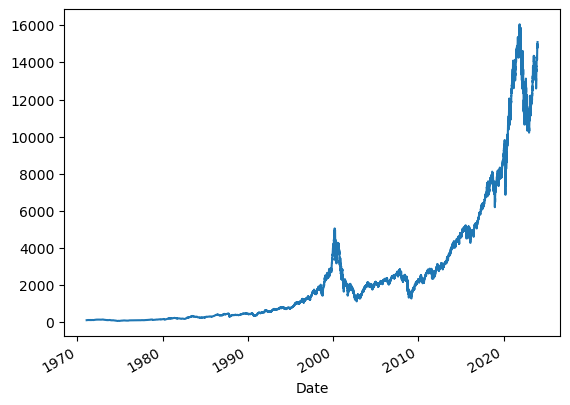

In [2]:
df=yf.Ticker("^IXIC")
df=df.history(period='max')
df['Close'].plot()

In [3]:
df.columns=df.columns.str.lower()
df.drop(['stock splits','dividends'],axis='columns',inplace=True)
df['date']=df.index
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['wday']=df['date'].dt.dayofweek
df.drop('date',axis='columns',inplace=True)
df=df[df['volume']!=0]
df['next_close']=df['close'].shift(-1)
df['next_open']=df['open'].shift(-1)
df.dropna(inplace=True)

In [4]:
df=df.reset_index(level=0)
df['Date'] = df['Date'].dt.tz_convert(None)

In [5]:
df['target']=(df['next_open']>df['open']).astype(int)

In [6]:
df['garman_val']=((np.log(df['high']) - np.log(df['low']))**2) / 2 - ((2 * np.log(2) - 1) * (np.log(df['close']) - np.log(df['high']))**2)

In [7]:
df.ta.rsi(length=20,append=True)
df.ta.bbands(length=20,append=True)
df.ta.atr(length=20,append=True)
df.ta.macd(length=20,append=True)

,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
9876,286.015894,40.109409,245.906484
9877,277.377687,25.176962,252.200725
9878,282.280859,24.064107,258.216752
9879,285.226836,21.608068,263.618769


In [8]:
df['dollar_volume']=(df['close']*df['volume'])/1e6
df

,Date,open,high,low,close,volume,year,month,wday,next_close,...,BBL_20_2.0,BBM_20_2.0,BBU_20_2.0,BBB_20_2.0,BBP_20_2.0,ATRr_20,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,dollar_volume
0,1984-10-11 04:00:00,244.199997,244.699997,244.199997,244.699997,62860000,1984,10,3,246.199997,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.538184e+04
1,1984-10-12 04:00:00,245.500000,246.199997,245.500000,246.199997,58860000,1984,10,4,247.699997,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.449133e+04
2,1984-10-15 04:00:00,246.800003,247.699997,246.800003,247.699997,61820000,1984,10,0,247.300003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.531281e+04
3,1984-10-16 04:00:00,247.800003,247.899994,247.100006,247.300003,57440000,1984,10,1,247.100006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.420491e+04
4,1984-10-17 04:00:00,247.100006,247.100006,246.800003,247.100006,64670000,1984,10,2,249.800003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.597996e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9876,2023-12-19 05:00:00,14923.019531,15003.799805,14921.599609,15003.219727,5757180000,2023,12,1,14777.940430,...,13904.557414,14425.931982,14947.306550,7.228296,1.053621,167.966223,286.015894,40.109409,245.906484,8.637624e+07
9877,2023-12-20 05:00:00,14973.360352,15069.290039,14776.290039,14777.940430,6294700000,2023,12,2,14963.870117,...,13922.794046,14454.829980,14986.865915,7.361359,0.803655,174.217911,277.377687,25.176962,252.200725,9.302270e+07
9878,2023-12-21 05:00:00,14923.139648,14970.809570,14837.469727,14963.870117,5465640000,2023,12,3,14992.969727,...,13921.511737,14489.730469,15057.949200,7.843055,0.917216,175.150473,282.280859,24.064107,258.216752,8.178713e+07
9879,2023-12-22 05:00:00,15006.179688,15047.190430,14927.120117,14992.969727,4796600000,2023,12,4,15074.570312,...,13929.674653,14526.836475,15123.998296,8.221499,0.890291,172.396465,285.226836,21.608068,263.618769,7.191528e+07


In [9]:
df.fillna(df.mean(),inplace=True)
df.isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_6556\2516141900.py:1: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  df.fillna(df.mean(),inplace=True)


Date             0
open             0
high             0
low              0
close            0
volume           0
year             0
month            0
wday             0
next_close       0
next_open        0
target           0
garman_val       0
RSI_20           0
BBL_20_2.0       0
BBM_20_2.0       0
BBU_20_2.0       0
BBB_20_2.0       0
BBP_20_2.0       0
ATRr_20          0
MACD_12_26_9     0
MACDh_12_26_9    0
MACDs_12_26_9    0
dollar_volume    0
dtype: int64

In [10]:
sentiment=pd.read_excel('sentiment.xlsx')
sentiment

,Unnamed: 0,date,compound
0,0,2019-04-23,0.000000
1,1,2019-05-14,0.000000
2,2,2019-08-08,0.340000
3,3,2019-08-09,0.000000
4,4,2019-09-05,0.000000
...,...,...,...
430,430,2023-12-24,0.276170
431,431,2023-12-25,0.315450
432,432,2023-12-26,0.142140
433,433,2023-12-27,0.266810


In [11]:
train_data=df.iloc[:int(0.99*len(df))]
test_data=df.iloc[int(0.99*len(df)):]

In [12]:
features=['open', 'high', 'low', 'close', 'volume', 'year', 'month', 'wday',
        'next_open', 'garman_val', 'RSI_20',
       'BBL_20_2.0', 'BBM_20_2.0', 'BBU_20_2.0', 'BBB_20_2.0', 'BBP_20_2.0',
       'ATRr_20', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
       'dollar_volume']

In [13]:
rg= RandomForestClassifier(n_estimators=50, min_samples_split=5, max_depth=20,min_samples_leaf=4)

In [14]:
rg.fit(train_data[features],train_data['target'])
rg.score(test_data[features],test_data['target'])

0.7070707070707071

In [15]:
X_train,X_test,y_train,y_test=train_test_split(df[features],df['target'])
rg.fit(X_train,y_train)
rg.score(X_test,y_test)

0.6635627530364372

In [16]:
param_grid = {
    'n_estimators': [10, 50, 100, 200,300],  
    'max_depth':  [10, 20, 30],       
    'min_samples_split': [2, 5, 10,15],     
    'min_samples_leaf': [1, 2, 4,6,8]      
}


grid_search = GridSearchCV(estimator=rg, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=20, min_samples_leaf=4,
                                              min_samples_split=5,
                                              n_estimators=50),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_leaf': [1, 2, 4, 6, 8],
                         'min_samples_split': [2, 5, 10, 15],
                         'n_estimators': [10, 50, 100, 200, 300]},
             scoring='accuracy')

In [17]:
params=pd.DataFrame(grid_search.cv_results_) 
params

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.267189,0.006578,0.008807,0.000749,10,1,2,10,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.628205,0.646424,0.630904,0.632254,0.643484,0.636254,0.007282,288
1,1.204454,0.011595,0.027820,0.002640,10,1,2,50,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.647099,0.659919,0.667341,0.655870,0.656989,0.657444,0.006539,206
2,2.417715,0.016124,0.049635,0.001626,10,1,2,100,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.646424,0.674089,0.668691,0.643725,0.669818,0.660549,0.012792,147
3,4.852843,0.077441,0.093066,0.002099,10,1,2,200,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.653171,0.670715,0.664642,0.657895,0.670493,0.663383,0.006932,71
4,7.297578,0.060767,0.136697,0.003723,10,1,2,300,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.647099,0.674089,0.668016,0.661943,0.665091,0.663248,0.009013,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.513564,0.050217,0.014611,0.004927,30,8,15,10,"{'max_depth': 30, 'min_samples_leaf': 8, 'min_...",0.643725,0.661269,0.641700,0.642375,0.631330,0.644080,0.009661,266
296,2.171340,0.072421,0.042631,0.014357,30,8,15,50,"{'max_depth': 30, 'min_samples_leaf': 8, 'min_...",0.656545,0.677463,0.666667,0.660594,0.667792,0.665812,0.007120,22
297,3.385802,0.217510,0.058242,0.001601,30,8,15,100,"{'max_depth': 30, 'min_samples_leaf': 8, 'min_...",0.653846,0.659244,0.657220,0.666667,0.672519,0.661899,0.006772,110
298,6.370521,0.257334,0.132094,0.036292,30,8,15,200,"{'max_depth': 30, 'min_samples_leaf': 8, 'min_...",0.646424,0.668691,0.668016,0.660594,0.678596,0.664464,0.010683,42


In [18]:
#data=pd.read_excel('factors.xls').dropna()

In [22]:
df.columns=df.columns.str.lower()

In [23]:
factors=pd.read_excel('factors.xls')
df['date']=pd.to_datetime(df['date'])
factors['date']=pd.to_datetime(factors['date'])
df['date'] = df['date'].dt.floor('D')
factors['date'] = factors['date'].dt.floor('D')
mix=pd.merge(df,factors,on='date')
mix

,date,open,high,low,close,volume,year,month,wday,next_close,...,bbb_20_2.0,bbp_20_2.0,atrr_20,macd_12_26_9,macdh_12_26_9,macds_12_26_9,dollar_volume,breakeven_inflation,fed_fund_eff,unrate
0,2003-01-02,1346.930054,1384.910034,1336.979980,1384.849976,1287540000,2003,1,3,1387.079956,...,7.457441,0.556251,32.800016,-10.093943,-4.110415,-5.983528,1.783050e+06,1.64,1.30,5.8
1,2003-01-03,1382.359985,1389.439941,1374.609985,1387.079956,1149590000,2003,1,4,1421.319946,...,6.675768,0.610733,31.901513,-7.827256,-1.474982,-6.352274,1.594573e+06,1.62,1.12,5.8
2,2003-01-06,1390.189941,1428.650024,1390.089966,1421.319946,1567690000,2003,1,0,1431.569946,...,6.927939,0.959930,32.384941,-3.230767,2.497206,-5.727972,2.228189e+06,1.63,1.22,5.8
3,2003-01-07,1424.260010,1442.260010,1416.229980,1431.569946,1755760000,2003,1,1,1401.069946,...,7.194538,1.041532,32.067195,1.224953,5.562340,-4.337387,2.513493e+06,1.62,1.20,5.8
4,2003-01-08,1423.290039,1424.119995,1399.060059,1401.069946,1457010000,2003,1,2,1438.459961,...,7.291498,0.713604,32.089330,2.268893,5.285025,-3.016131,2.041373e+06,1.71,1.29,5.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5270,2023-12-08,14279.459961,14416.919922,14264.959961,14403.969727,5430840000,2023,12,4,14432.490234,...,4.357823,0.860553,178.346148,200.068961,-14.557803,214.626764,7.822565e+07,2.21,5.33,3.7
5271,2023-12-11,14340.129883,14436.080078,14324.570312,14432.490234,5607820000,2023,12,0,14533.400391,...,3.847112,0.901656,175.004329,201.774279,-10.281988,212.056267,8.093481e+07,2.19,5.33,3.7
5272,2023-12-12,14423.009766,14533.400391,14385.389648,14533.400391,4950100000,2023,12,1,14733.959961,...,3.131829,1.132384,173.654649,208.860746,-2.556417,211.417162,7.194179e+07,2.16,5.33,3.7
5273,2023-12-13,14555.679688,14743.549805,14517.519531,14733.959961,6732040000,2023,12,2,14761.559570,...,4.139991,1.262408,176.273430,228.031695,13.291626,214.740069,9.918961e+07,2.16,5.33,3.7


In [24]:
mix['breakeven_inflation']=mix['breakeven_inflation'].fillna(mix['breakeven_inflation'].mean())
mix.isna().sum()

date                   0
open                   0
high                   0
low                    0
close                  0
volume                 0
year                   0
month                  0
wday                   0
next_close             0
next_open              0
target                 0
garman_val             0
rsi_20                 0
bbl_20_2.0             0
bbm_20_2.0             0
bbu_20_2.0             0
bbb_20_2.0             0
bbp_20_2.0             0
atrr_20                0
macd_12_26_9           0
macdh_12_26_9          0
macds_12_26_9          0
dollar_volume          0
breakeven_inflation    0
fed_fund_eff           0
unrate                 0
dtype: int64

In [25]:
train_data=mix.iloc[:int(len(mix)*0.99)]
test_data=mix.iloc[int(len(mix)*0.99):]

In [26]:
features=[ 'open', 'high', 'low', 'close', 'volume', 'year', 'month',
       'wday', 'next_close', 'next_open', 'garman_val', 'rsi_20',
       'bbl_20_2.0', 'bbm_20_2.0', 'bbu_20_2.0', 'bbb_20_2.0', 'bbp_20_2.0',
       'atrr_20', 'macd_12_26_9', 'macdh_12_26_9', 'macds_12_26_9',
       'dollar_volume', 'breakeven_inflation', 'fed_fund_eff', 'unrate']

In [27]:
rg= RandomForestClassifier(n_estimators=50, min_samples_split=5, max_depth=20,min_samples_leaf=4)

In [29]:
rg.fit(train_data[features],train_data['target'])
rg.score(test_data[features],test_data['target'])

0.6981132075471698